# Rock, Paper, Scissors Classification Model
- 3 classes/poses: rock, paper, scissors
  - 1 sample has 5 * 6  features (for now)?
- Classification neural net

https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/02_pytorch_classification.ipynb#scrollTo=Z2gcR31aHC78

## Ablation

https://docs.google.com/spreadsheets/d/1Xy92hWhrxcyvLkxY7Q0RPff1FNVfsLxV0ujrjC6SdFE/edit?gid=427952541#gid=427952541

In [1]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import asyncio
import websockets
import json

import gc
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, MinMaxScaler

In [2]:
print(torch.__version__)
print(torch._dynamo.__file__)


2.11.0+cu128
/home/amiou/Code/Capstone/ECE-SP-26-18-Capstone-Project/venv/lib/python3.14/site-packages/torch/_dynamo/__init__.py


In [3]:
EPOCHS = 2000
SEED = 40

STD = 0.02
COPY = 5
HIDDEN = 0 # No consistent hidden layers in other models
DROPOUT = 0.1

# Set BATCH_SIZE to the full training dataset size for now
# BATCH_SIZE = len(X_train)
LR = 1e-3
WEIGHT_DECAY = 1e-5
# LR = 1

N_FOLDS = 5

In [4]:
df = pd.read_csv("data/Glove_v2_norm/everything_v2.csv")
df = df.drop(columns=["time"], errors='ignore')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71115 entries, 0 to 71114
Data columns (total 55 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   BNO0_UnitAccX   71115 non-null  float64
 1   BNO0_UnitAccY   71115 non-null  float64
 2   BNO0_UnitAccZ   71115 non-null  float64
 3   BNO0_RawAccMag  71115 non-null  float64
 4   BNO0_GyrX       71115 non-null  float64
 5   BNO0_GyrY       71115 non-null  float64
 6   BNO0_GyrZ       71115 non-null  float64
 7   BNO0_MagX       71115 non-null  float64
 8   BNO0_MagY       71115 non-null  float64
 9   BNO0_MagZ       71115 non-null  float64
 10  BNO1_UnitAccX   71115 non-null  float64
 11  BNO1_UnitAccY   71115 non-null  float64
 12  BNO1_UnitAccZ   71115 non-null  float64
 13  BNO1_RawAccMag  71115 non-null  float64
 14  BNO1_GyrX       71115 non-null  float64
 15  BNO1_GyrY       71115 non-null  float64
 16  BNO1_GyrZ       71115 non-null  float64
 17  BNO1_MagX       71115 non-null  float64
 1

In [5]:
def augment_with_noise(df, label_col="label", noise_fraction=0.05, copies=3, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
        
    # Isolate only numeric columns, ignoring the label
    features_df = df.drop(columns=[label_col], errors='ignore')
    numeric_cols = features_df.select_dtypes(include=[np.number]).columns
    
    augmented_dfs = [df]  # keep original

    # Calculate the standard deviation for each numeric column
    col_stds = df[numeric_cols].std().values

    for _ in range(copies):
        noisy_df = df.copy()
        
        # Generate noise proportional to each column's standard deviation
        noise = np.random.normal(
            loc=0,
            scale=col_stds * noise_fraction, 
            size=(len(df), len(numeric_cols))
        )
        
        noisy_df[numeric_cols] = noisy_df[numeric_cols] + noise
        augmented_dfs.append(noisy_df)

    return pd.concat(augmented_dfs, ignore_index=True)

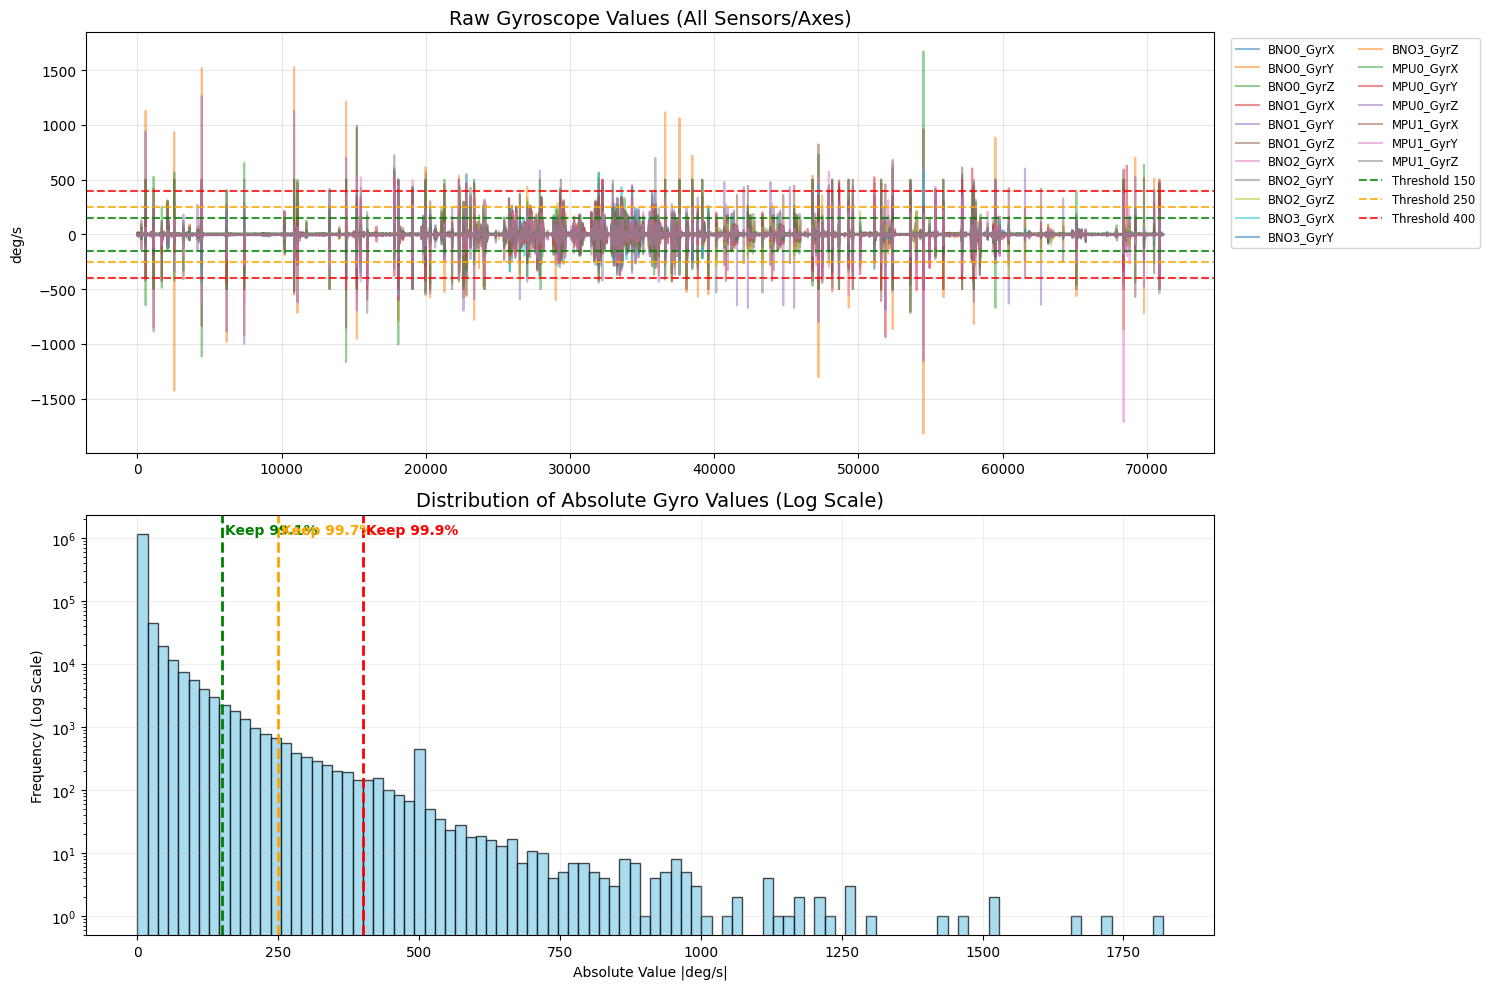


--- Data Retention Summary ---
Threshold 100: Keeps  98.34% of samples
Threshold 150: Keeps  99.14% of samples
Threshold 200: Keeps  99.52% of samples
Threshold 250: Keeps  99.70% of samples
Threshold 300: Keeps  99.80% of samples
Threshold 400: Keeps  99.89% of samples
Threshold 500: Keeps  99.94% of samples


In [6]:
def visualize_gyro_thresholds(df):
    # 1. Identify gyro columns
    gyro_cols = [col for col in df.columns if 'gyr' in col.lower()]
    if not gyro_cols:
        print("No gyroscope columns found!")
        return

    # Flatten all absolute gyro values into one array for distribution analysis
    all_gyro_abs = df[gyro_cols].abs().values.flatten()
    
    # Setup plotting area
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

    # --- Plot 1: Time Series (The "Spike" View) ---
    for col in gyro_cols:
        ax1.plot(df[col], alpha=0.5, label=col)
    
    # Add reference lines for potential thresholds
    test_thresholds = [150, 250, 400]
    colors = ['green', 'orange', 'red']
    for t, c in zip(test_thresholds, colors):
        ax1.axhline(t, color=c, linestyle='--', alpha=0.8, label=f'Threshold {t}')
        ax1.axhline(-t, color=c, linestyle='--', alpha=0.8)

    ax1.set_title("Raw Gyroscope Values (All Sensors/Axes)", fontsize=14)
    ax1.set_ylabel("deg/s")
    ax1.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=2)
    ax1.grid(True, alpha=0.3)

    # --- Plot 2: Histogram (The "Data Loss" View) ---
    # Use log scale for Y so we can see the rare outliers/spikes easily
    ax2.hist(all_gyro_abs, bins=100, color='skyblue', edgecolor='black', alpha=0.7, log=True)
    
    for t, c in zip(test_thresholds, colors):
        # Calculate how much data is KEPT at this threshold
        percent_kept = (all_gyro_abs <= t).mean() * 100
        ax2.axvline(t, color=c, linestyle='--', linewidth=2)
        ax2.text(t+5, ax2.get_ylim()[1]*0.5, f"Keep {percent_kept:.1f}%", color=c, fontweight='bold')

    ax2.set_title("Distribution of Absolute Gyro Values (Log Scale)", fontsize=14)
    ax2.set_xlabel("Absolute Value |deg/s|")
    ax2.set_ylabel("Frequency (Log Scale)")
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    # Print a quick summary table
    print("\n--- Data Retention Summary ---")
    for t in [100, 150, 200, 250, 300, 400, 500]:
        percent = (all_gyro_abs <= t).mean() * 100
        print(f"Threshold {t:3}: Keeps {percent:6.2f}% of samples")

# Assuming 'df' is your loaded DataFrame
visualize_gyro_thresholds(df)

In [7]:
# 1. Define the list of labels you want to keep
# Make sure these match the exact strings in your CSV
labels_to_keep = ['none', 'point left', 'point right']

# 2. Filter the DataFrame
# We use .str.lower() and .str.strip() to handle typos like "Rock " or "ROCK"
df_filtered = df[df['label'].str.lower().str.strip().isin(labels_to_keep)].copy()

# 3. Verify the results
print(f"Original unique labels: {df['label'].unique()}")
print(f"Filtered unique labels: {df_filtered['label'].unique()}")
print(f"Remaining rows: {len(df_filtered)}")

# 4. Optional: Reset the index 
# This prevents issues later when splitting or converting to tensors
df_filtered = df_filtered.reset_index(drop=True)
df = df_filtered

Original unique labels: <StringArray>
[       'none',        'rock',       'paper',    'scissors',           'A',
           'B',           'X',           'Y',  'pinch open', 'pinch close',
 'point right',  'point left']
Length: 12, dtype: str
Filtered unique labels: <StringArray>
['none', 'point right', 'point left']
Length: 3, dtype: str
Remaining rows: 32975


In [8]:
df

,BNO0_UnitAccX,BNO0_UnitAccY,BNO0_UnitAccZ,BNO0_RawAccMag,BNO0_GyrX,BNO0_GyrY,BNO0_GyrZ,BNO0_MagX,BNO0_MagY,BNO0_MagZ,...,MPU0_GyrY,MPU0_GyrZ,MPU1_UnitAccX,MPU1_UnitAccY,MPU1_UnitAccZ,MPU1_RawAccMag,MPU1_GyrX,MPU1_GyrY,MPU1_GyrZ,label
0,0.199,0.948,-0.247,2605.50,4.476,-6.938,10.295,-0.354,-0.607,0.711,...,-2.382,1.053,0.857,0.243,-0.454,10.205,0.107,-6.412,1.298,none
1,0.211,0.941,-0.266,2417.36,8.057,-1.343,8.393,-0.377,-0.582,0.720,...,-5.573,-1.038,0.845,0.337,-0.416,10.581,3.969,-8.458,-0.305,none
2,0.208,0.943,-0.261,2538.87,7.274,-0.783,11.862,-0.387,-0.629,0.674,...,-5.863,-1.008,0.839,0.370,-0.398,10.872,2.901,-8.794,0.107,none
3,0.324,0.908,-0.266,2602.55,-2.686,-0.671,-1.007,-0.384,-0.650,0.656,...,0.168,2.489,0.863,0.226,-0.451,10.398,-2.824,-4.779,2.794,none
4,0.179,0.950,-0.257,2465.79,1.567,-3.581,2.014,-0.381,-0.646,0.662,...,-1.908,2.885,0.858,0.232,-0.457,10.289,0.580,-5.756,3.160,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32970,0.612,-0.237,-0.754,2469.13,0.112,-0.112,0.000,-0.941,0.232,0.246,...,0.198,-1.420,0.848,0.396,0.353,10.328,-5.542,-4.824,-0.977,none
32971,0.610,-0.237,-0.756,2477.43,0.112,0.224,0.000,-0.946,0.207,0.250,...,0.382,-1.389,0.850,0.396,0.347,10.314,-5.603,-4.779,-0.687,none
32972,0.614,-0.237,-0.753,2475.40,-0.112,-0.224,0.112,-0.948,0.213,0.235,...,0.580,-1.542,0.848,0.398,0.350,10.317,-5.740,-4.534,-0.733,none
32973,0.614,-0.238,-0.753,2463.85,0.448,-0.112,0.336,-0.941,0.223,0.254,...,0.595,-1.557,0.849,0.396,0.349,10.321,-5.710,-4.504,-0.672,none


In [9]:
def filter_gyro_spikes(df, threshold=250.0):
    """
    Removes rows where any gyroscope value (absolute) exceeds the threshold.
    """
    # Identify all columns that contain gyroscope data
    gyro_cols = [col for col in df.columns if 'gyr' in col.lower()]
    
    # Create a mask where True means the row is "clean"
    # (All gyro values in that row are <= threshold)
    clean_mask = (df[gyro_cols].abs() <= threshold).all(axis=1)
    
    df_filtered = df[clean_mask].copy()
    
    rows_removed = len(df) - len(df_filtered)
    print(f"Filtered {rows_removed} rows containing gyro spikes > {threshold}")
    
    return df_filtered

def drop_gyro_columns(df):
    """
    Removes all columns related to gyroscope readings.
    """
    gyro_cols = [col for col in df.columns if 'gyr' in col.lower()]
    df_dropped = df.drop(columns=gyro_cols)
    
    print(f"Dropped {len(gyro_cols)} gyroscope columns.")
    return df_dropped

In [10]:
import pandas as pd

def get_window_data(df, window_size):
    # 1. Separate features and label
    features_df = df.drop(columns=['label']).copy()
    
    # 2. Numeric conversion for features
    features_df = features_df.apply(pd.to_numeric, errors='coerce').fillna(0)

    # 3. Calculate Rolling Mean and Variance
    rolling_mean = features_df.rolling(window=window_size).mean()
    rolling_var = features_df.rolling(window=window_size).var()
    
    rolling_mean.columns = [f"{name}_mean" for name in features_df.columns]
    rolling_var.columns = [f"{name}_var" for name in features_df.columns]

    combined_df = pd.concat([rolling_mean, rolling_var], axis=1)

    # 4. HANDLE LABELS: Map to integers first
    # Create a mapping (e.g., 'none': 0, 'paper': 1, etc.)
    unique_labels = df['label'].unique()
    label_to_id = {label: i for i, label in enumerate(unique_labels)}
    id_to_label = {i: label for label, i in label_to_id.items()}
    
    temp_label_ids = df['label'].map(label_to_id)

    # 5. Calculate Mode on the integer IDs
    # Now that it's numeric, rolling().apply() will work!
    combined_df['label'] = (
        temp_label_ids
        .rolling(window=window_size)
        .apply(lambda x: pd.Series(x).mode()[0], raw=False)
    )

    # 6. Map back to strings
    combined_df['label'] = combined_df['label'].map(id_to_label)

    # 7. Drop NaNs and reset
    return combined_df.dropna().reset_index(drop=True)

In [11]:
# 1. Clean the data based on movement intensity
df = filter_gyro_spikes(df, threshold=150.0)

# 2. Strip the gyro features if you want a purely static-pose model
df = drop_gyro_columns(df)

Filtered 1337 rows containing gyro spikes > 150.0
Dropped 18 gyroscope columns.


In [12]:
df.head(5)

,BNO0_UnitAccX,BNO0_UnitAccY,BNO0_UnitAccZ,BNO0_RawAccMag,BNO0_MagX,BNO0_MagY,BNO0_MagZ,BNO1_UnitAccX,BNO1_UnitAccY,BNO1_UnitAccZ,...,BNO3_MagZ,MPU0_UnitAccX,MPU0_UnitAccY,MPU0_UnitAccZ,MPU0_RawAccMag,MPU1_UnitAccX,MPU1_UnitAccY,MPU1_UnitAccZ,MPU1_RawAccMag,label
0,0.199,0.948,-0.247,2605.50,-0.354,-0.607,0.711,0.279,0.943,-0.181,...,0.370,0.965,0.056,-0.255,9.359,0.857,0.243,-0.454,10.205,none
1,0.211,0.941,-0.266,2417.36,-0.377,-0.582,0.720,0.288,0.935,-0.209,...,0.358,0.964,0.150,-0.220,9.789,0.845,0.337,-0.416,10.581,none
2,0.208,0.943,-0.261,2538.87,-0.387,-0.629,0.674,0.288,0.935,-0.209,...,0.357,0.961,0.188,-0.205,10.128,0.839,0.370,-0.398,10.872,none
3,0.324,0.908,-0.266,2602.55,-0.384,-0.650,0.656,0.370,0.909,-0.193,...,0.361,0.967,0.032,-0.252,9.517,0.863,0.226,-0.451,10.398,none
4,0.179,0.950,-0.257,2465.79,-0.381,-0.646,0.662,0.247,0.950,-0.194,...,0.328,0.967,0.045,-0.253,9.430,0.858,0.232,-0.457,10.289,none


In [13]:
# df = get_window_data(df, 5)

In [14]:
# 1. Split FIRST to prevent data leakage. 
# stratify=df['label'] ensures the 1000 test rows have the correct class proportions.
df_train, testing = train_test_split(df, test_size=100, stratify=df['label'], random_state=42)

# Reset indices for cleanliness
df_train = df_train.reset_index(drop=True)
testing = testing.reset_index(drop=True)

# 2. Balance the TRAINING data only
min_count = df_train['label'].value_counts().min()
df_balanced = df_train.groupby('label').sample(n=min_count, random_state=42).reset_index(drop=True)

print("Balanced Training Class Counts:")
print(df_balanced['label'].value_counts())

# Now 'df_balanced' is ready for your augment_with_noise() function!
# df = df_balanced

Balanced Training Class Counts:
label
none           2050
point left     2050
point right    2050
Name: count, dtype: int64


In [15]:

# Print original size with context
print(f"Original row count: {len(df)}")

augmented_df = augment_with_noise(
    df,
    label_col="label",
    noise_fraction=0.0005, # Using the updated parameter from the previous cell
    copies=COPY,
    random_state=42      # Using the new reproducibility parameter
)

print(f"Augmented row count: {len(augmented_df)}")

# If you must overwrite df to save memory, do it at the very end
df = augmented_df

Original row count: 31638
Augmented row count: 189828


In [16]:
df_train  = df
df_train.label.value_counts()

label
none           161034
point right     16458
point left      12336
Name: count, dtype: int64

## Make data and label dfs


In [17]:
# Scramble the rows
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
# df_all = df_all.drop(columns=["time"])
df_train.head(3)

,BNO0_UnitAccX,BNO0_UnitAccY,BNO0_UnitAccZ,BNO0_RawAccMag,BNO0_MagX,BNO0_MagY,BNO0_MagZ,BNO1_UnitAccX,BNO1_UnitAccY,BNO1_UnitAccZ,...,BNO3_MagZ,MPU0_UnitAccX,MPU0_UnitAccY,MPU0_UnitAccZ,MPU0_RawAccMag,MPU1_UnitAccX,MPU1_UnitAccY,MPU1_UnitAccZ,MPU1_RawAccMag,label
0,0.945875,0.286067,-0.153044,1797.110886,-0.865310,-0.423993,0.267699,0.951981,0.149323,-0.267823,...,0.117848,0.465074,0.866660,0.179693,8.137500,0.298077,0.930828,-0.207163,8.095982,none
1,-0.507165,0.861810,0.017958,2402.654489,0.293077,-0.888922,-0.352246,0.226803,0.341386,-0.911594,...,0.276228,0.930247,-0.271214,-0.249855,9.949847,0.907202,-0.327040,-0.262741,10.691111,point left
2,0.475270,-0.266999,-0.839366,2448.902335,-0.482955,0.126409,0.866213,0.699149,-0.295113,-0.652110,...,-0.054964,0.460316,0.196596,0.865171,10.916752,0.681361,0.424378,0.596846,10.127826,none


In [18]:
# Select only columns that contain text (strings or objects)
text_cols = df_train.select_dtypes(include=['object', 'string']).columns

# Strip leading and trailing whitespace from those columns
df_train[text_cols] = df_train[text_cols].apply(lambda x: x.str.strip())

In [19]:
# 1. Get all unique labels and sort them alphabetically to guarantee consistency
unique_labels = sorted(df_train["label"].unique())

# 2. Dynamically generate the dictionary using enumerate
mapping = {label: idx for idx, label in enumerate(unique_labels)}

# Print the mapping so you know exactly what the model is learning!
print(f"Dynamic mapping generated: {mapping}")

y_train = df_train["label"].map(mapping)

# 2. Safety check: Ensure no labels were misspelled and turned into NaNs
if y_train.isna().any():
    print("WARNING: Some labels were not in the mapping dictionary and became NaN!")
    print(df_train[y_train.isna()]['label'].unique()) # Show the problem labels

# 3. Separate the features (X) from the labels (y)
X_train = df_train.drop(columns=["label"])

Dynamic mapping generated: {'none': 0, 'point left': 1, 'point right': 2}


In [20]:
# torch.tensor() creates a clean copy, removing the read-only warning
# .to_numpy() is the modern pandas standard
X = torch.tensor(X_train.to_numpy()).type(torch.float)
y = torch.tensor(y_train.to_numpy()).type(torch.long)

# Split data into train and validation sets
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X,
    y,
    test_size=0.2, 
    stratify=y,       
    random_state=42
)

print(f"Training rows: {len(X_train_final)}, Validation rows: {len(X_val)}")

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"  # Force CPU for now to avoid GPU issues
print(f"Using device: {device}")

Training rows: 151862, Validation rows: 37966
Using device: cuda


In [21]:
# Clean up trailing references
gc.collect()

# Empty the GPU VRAM cache
if device == "cuda":
    torch.cuda.empty_cache()

In [22]:
y

tensor([0, 1, 0,  ..., 0, 0, 0])

# Model Training

In [23]:
# Dynamically get input features from your PyTorch training tensor
input_features = X_train_final.shape[1]

# Dynamically count the number of unique classes from your label tensor
classes = len(torch.unique(y_train_final))

# Set hidden units (assuming HIDDEN is defined earlier)
hidden_units = HIDDEN

# Clearly print the architecture parameters
print(f"Input features: {input_features}")
print(f"Output classes: {classes}")
print(f"Hidden units: {hidden_units}")

Input features: 36
Output classes: 3
Hidden units: 0


In [24]:
# MODEL 4
class RPSModel(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, output_features)
        )

    def forward(self, x):
        return self.net(x)

In [25]:
# Create an instance of the model and send it to target device
model_4 = RPSModel(
    input_features=input_features, 
    output_features=classes
).to(device)

# Create a loss function
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer (Upgraded to Adam for faster/better convergence)
optimizer = optim.Adam(params=model_4.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                 mode='min', 
                                                 factor=0.5, 
                                                 patience=20)
# Calculate accuracy with a device-safety check
def accuracy_fn(y_true, y_pred):
    # Ensure both tensors are on the same device before comparing
    if y_true.device != y_pred.device:
        y_pred = y_pred.to(y_true.device)
        
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

#Training

In [26]:
# Set the seed if you want the exact same "random" number every time
random.seed(42) 

random_integer = random.randint(1, 100)
print(f"Random integer: {random_integer}")

Random integer: 82


# Training Loop

In [27]:
# # 1. Use the corrected variable names from our earlier split
# X_train_tensor, y_train_tensor = X_train_final.to(device), y_train_final.to(device)
# X_val_tensor, y_val_tensor = X_val.to(device), y_val.to(device)

# # 2. Create a DataLoader for Mini-Batch training
# # A batch size of 32 or 64 is standard for tabular data
# BATCH_SIZE = 2**14
# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# torch.manual_seed(SEED)
# epochs = EPOCHS
# train_losses, val_losses = [], []

# for epoch in range(epochs):
#     ### Training Phase
#     model_4.train()
#     total_train_loss, total_train_acc = 0, 0
    
#     # Loop through the data in batches!
#     for batch_X, batch_y in train_dataloader:
#         y_logits = model_4(batch_X) 
#         y_pred = torch.argmax(y_logits, dim=1)
        
#         loss = loss_fn(y_logits, batch_y)
#         acc = accuracy_fn(y_true=batch_y, y_pred=y_pred) 
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         total_train_loss += loss.item()
#         total_train_acc += acc
        
#     # Average loss and accuracy across all batches
#     avg_train_loss = total_train_loss / len(train_dataloader)
#     avg_train_acc = total_train_acc / len(train_dataloader)

#     ### Evaluation Phase (Validation Set)
#     model_4.eval()
#     with torch.inference_mode():
#         # Validation can usually handle the full dataset at once if it fits in memory
#         val_logits = model_4(X_val_tensor)
#         val_pred = torch.argmax(val_logits, dim=1)
        
#         val_loss = loss_fn(val_logits, y_val_tensor)
#         val_acc = accuracy_fn(y_true=y_val_tensor, y_pred=val_pred)

#     # Record losses
#     train_losses.append(avg_train_loss)
#     val_losses.append(val_loss.item())

#     # The scheduler looks at the validation loss
#     scheduler.step(val_loss)
    
#     # Track the current learning rate to see it changing
#     current_lr = optimizer.param_groups[0]['lr']
    
#     if epoch % 10 == 0: 
#         print(f"Epoch: {epoch: <4} | LR: {current_lr:.10f} | Val Loss: {val_loss:.5f} | Val Acc: {val_acc:.2f}%")

In [28]:
# 1. Use the corrected variable names from our earlier split
X_train_tensor, y_train_tensor = X_train_final.to(device), y_train_final.to(device)
X_val_tensor, y_val_tensor = X_val.to(device), y_val.to(device)

torch.manual_seed(SEED)
epochs = EPOCHS
train_losses, val_losses = [], []

for epoch in range(epochs):
    ### Training Phase
    model_4.train()
    
    # Forward pass on the ENTIRE dataset at once
    y_logits = model_4(X_train_tensor) 
    y_pred = torch.argmax(y_logits, dim=1)
    
    # Calculate loss and accuracy for the full dataset
    loss = loss_fn(y_logits, y_train_tensor)
    acc = accuracy_fn(y_true=y_train_tensor, y_pred=y_pred) 
    
    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
        
    ### Evaluation Phase (Validation Set)
    model_4.eval()
    with torch.inference_mode():
        # Validation on the full dataset
        val_logits = model_4(X_val_tensor)
        val_pred = torch.argmax(val_logits, dim=1)
        
        val_loss = loss_fn(val_logits, y_val_tensor)
        val_acc = accuracy_fn(y_true=y_val_tensor, y_pred=val_pred)

    # Record losses
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    # The scheduler looks at the validation loss
    scheduler.step(loss)
    
    # Track the current learning rate to see it changing
    current_lr = optimizer.param_groups[0]['lr']
    
    if epoch % 10 == 0: 
        # Added Train Loss to the print statement for better tracking
        print(f"Epoch: {epoch: <4} | LR: {current_lr:.10f} | Train Loss: {loss:.5f} | Val Loss: {val_loss:.5f} | Val Acc: {val_acc:.2f}%")

/home/amiou/Code/Capstone/ECE-SP-26-18-Capstone-Project/venv/lib/python3.14/site-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Epoch: 0    | LR: 0.0010000000 | Train Loss: 1.18915 | Val Loss: 0.64598 | Val Acc: 84.81%
Epoch: 10   | LR: 0.0010000000 | Train Loss: 0.98347 | Val Loss: 1.01616 | Val Acc: 82.04%
Epoch: 20   | LR: 0.0010000000 | Train Loss: 0.83909 | Val Loss: 0.99991 | Val Acc: 83.32%
Epoch: 30   | LR: 0.0010000000 | Train Loss: 0.71917 | Val Loss: 0.96928 | Val Acc: 84.54%
Epoch: 40   | LR: 0.0010000000 | Train Loss: 0.63629 | Val Loss: 0.86920 | Val Acc: 84.76%
Epoch: 50   | LR: 0.0010000000 | Train Loss: 0.56707 | Val Loss: 0.65954 | Val Acc: 84.83%
Epoch: 60   | LR: 0.0010000000 | Train Loss: 0.50674 | Val Loss: 0.53701 | Val Acc: 84.83%
Epoch: 70   | LR: 0.0010000000 | Train Loss: 0.44787 | Val Loss: 0.52723 | Val Acc: 84.83%
Epoch: 80   | LR: 0.0010000000 | Train Loss: 0.39965 | Val Loss: 0.54716 | Val Acc: 84.83%
Epoch: 90   | LR: 0.0010000000 | Train Loss: 0.35948 | Val Loss: 0.49543 | Val Acc: 84.82%
Epoch: 100  | LR: 0.0010000000 | Train Loss: 0.31720 | Val Loss: 0.81599 | Val Acc: 77.59%

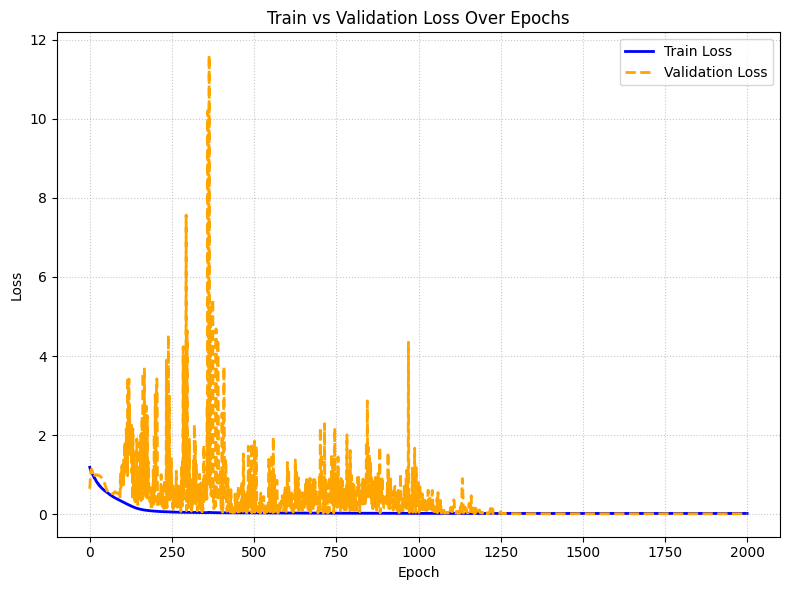

In [29]:
plt.figure(figsize=(8, 6))

# Updated to use val_losses to match the previous cell's corrections!
plt.plot(train_losses, label="Train Loss", color='blue', linewidth=2)
plt.plot(val_losses, label="Validation Loss", color='orange', linewidth=2, linestyle='--')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss Over Epochs")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Model Saving

In [30]:
def save_model():
    # 1. Save the Model Weights
    model_path = "model.pth"
    torch.save(model_4.state_dict(), model_path)

    # 2. Save the Metadata (Mapping and Feature Order)
    # We save this as a JSON so it's readable by any Python script later
    metadata = {
        "input_features": X_train.shape[1],
        "output_classes": classes,
        "gesture_mapping": {v: k for k, v in mapping.items()}, # {0: 'rock', ...}
        "feature_names": list(X_train.columns),
        "confidence_threshold": 0.82
    }

    with open("model_metadata.json", "w") as f:
        json.dump(metadata, f, indent=4)

    print(f"Model saved to {model_path}")
    print("Metadata and feature order saved to model_metadata.json")

def run_model():
    # 1. Re-define the class (PyTorch needs the architecture definition)
    class RPSModel(nn.Module):
        def __init__(self, input_features, output_features):
            super().__init__()
            self.linear_layer_stack = nn.Sequential(
                nn.Linear(in_features=input_features, out_features=32),
                nn.ReLU(),
                nn.Dropout(p=DROPOUT),

                nn.Linear(in_features=32, out_features=16),
                nn.ReLU(),
                nn.Dropout(p=DROPOUT),

                nn.Linear(in_features=16, out_features=output_features)
            )

        # 3. Define a forward method containing the forward pass computation
        def forward(self, x):
            return self.linear_layer_stack(x)    # ... (paste your RPSModel class code here) ...

    # 2. Load Metadata
    with open("model_metadata.json", "r") as f:
        meta = json.load(f)

    # 3. Instantiate and Load Weights
    loaded_model = RPSModel(input_features=meta["input_features"], 
                            output_features=meta["output_classes"]).to(device)
    loaded_model.load_state_dict(torch.load("model.pth"))
    loaded_model.eval()

    print("Model successfully reconstructed!")

In [31]:
save_model()

Model saved to model.pth
Metadata and feature order saved to model_metadata.json


# Testing

In [32]:
# 1. Safely copy the test set to avoid modifying the original data
testing_prep = testing.copy()

# 2. Apply the dynamic mapping we generated earlier
testing_prep["label"] = testing_prep["label"].map(mapping)

# 3. Setup Visualization Constants
# Define display labels FIRST
display_labels = ["Paper", "Rock", "Scissors", "None"]
num_classes = len(display_labels)

# Use modern matplotlib syntax
cmap = plt.colormaps.get_cmap("gist_rainbow")

# Generate exactly 4 colors based on the length of your display labels
colors = cmap(np.linspace(0, 1, num_classes))

# Set confidence threshold for predictions
conf_thres = 0.7

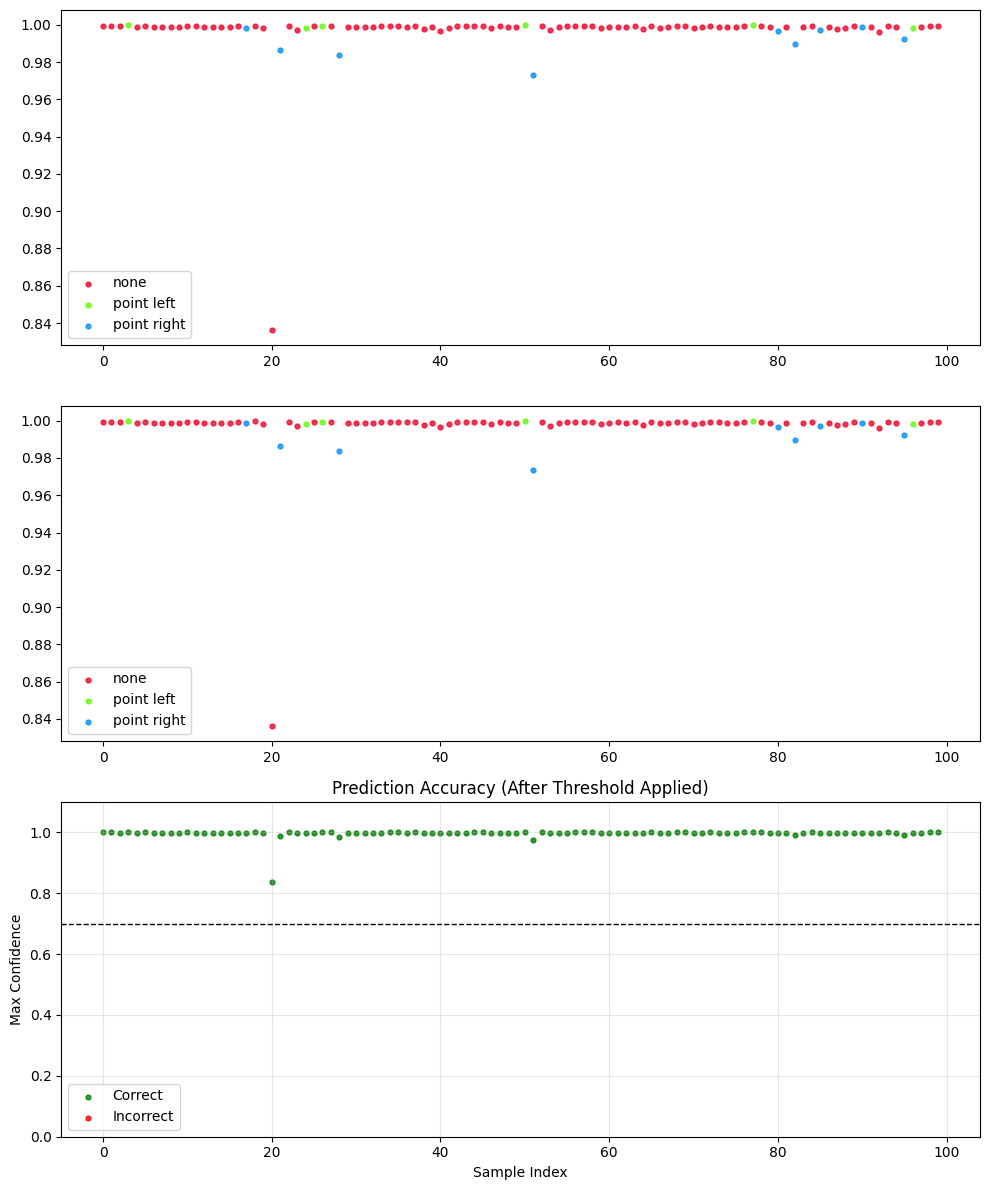

In [33]:
# ------------------------
# Prepare Test Features
# ------------------------
true_labels1 = testing_prep['label'] # Using the safely copied dataframe from the previous cell
X_features = testing_prep.drop(columns=['label'])

# Vectorized coercion (much faster than a for loop)
X_features = X_features.apply(pd.to_numeric, errors='coerce').fillna(0)

# Align columns with the training data's features (Update the variable name here if needed)
# Use the pandas DataFrame from earlier in your pipeline
X_features = X_features[X_train.columns]

X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# ------------------------
# Inference
# ------------------------
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    new_probs = torch.softmax(new_logits, dim=1)
    # Get the highest probability and the corresponding class index
    max_probs, max_classes = torch.max(new_probs, dim=1)

# Convert to numpy for matplotlib and thresholding
max_probs = max_probs.cpu().numpy()
max_classes = max_classes.cpu().numpy()
true_numeric1 = true_labels1.reset_index(drop=True).values

# ------------------------
# Prepare thresholded predictions (FIXED LOGIC)
# ------------------------
pred_classes_thresh = max_classes.copy()

# Look up the actual integer mapped to 'none' in your dictionary (it should be 3)
existing_none_idx = mapping.get('none', 3) 

# If confidence is below threshold, set prediction to the existing 'none' class
pred_classes_thresh[max_probs < conf_thres] = existing_none_idx

# ------------------------
# Create 3 subplots
# ------------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# Ensure max_classes is integers, not floats
max_classes = max_classes.astype(int)
pred_classes_thresh = pred_classes_thresh.astype(int)

# ------------------------
# Plot 1: Updated Loop
# ------------------------
for label, class_idx in mapping.items(): # mapping.items() gives (str, int)
    mask = (max_classes == class_idx)
    indices = np.flatnonzero(mask)
    
    # We use the label in the scatter call so the legend picks it up
    color = plt.colormaps.get_cmap("gist_rainbow")(class_idx / len(mapping))
    
    if len(indices) > 0:
        ax1.scatter(
            indices, 
            max_probs[indices], 
            s=12, 
            alpha=0.8, 
            label=label, # This is what the legend looks for!
            color=color
        )

# Check if anything was actually plotted before calling legend to avoid the warning
if ax1.get_legend_handles_labels()[0]:
    ax1.legend()

# ------------------------
# Plot 2: Updated Loop
# ------------------------
for label, class_idx in mapping.items():
    mask = (pred_classes_thresh == class_idx)
    indices = np.flatnonzero(mask)
    
    color = plt.colormaps.get_cmap("gist_rainbow")(class_idx / len(mapping))
    
    if len(indices) > 0:
        ax2.scatter(
            indices, 
            max_probs[indices], 
            s=12, 
            alpha=0.8, 
            label=label, 
            color=color
        )

if ax2.get_legend_handles_labels()[0]:
    ax2.legend()
# ------------------------
# Plot 3: Correct vs Incorrect (threshold applied)
# ------------------------
correct_mask_thresh = pred_classes_thresh == true_numeric1
incorrect_mask_thresh = pred_classes_thresh != true_numeric1

correct_idx = np.flatnonzero(correct_mask_thresh)
incorrect_idx = np.flatnonzero(incorrect_mask_thresh)

ax3.scatter(correct_idx, max_probs[correct_idx], s=12, alpha=0.8, label="Correct", color="green")
ax3.scatter(incorrect_idx, max_probs[incorrect_idx], s=12, alpha=0.8, label="Incorrect", color="red")

ax3.set_xlabel("Sample Index")
ax3.set_ylabel("Max Confidence")
ax3.set_ylim(0, 1.1)
ax3.set_title("Prediction Accuracy (After Threshold Applied)")
ax3.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Live Data Sim

In [34]:
# 1. Load and clean
df_test = pd.read_csv("data/Glove_v2_norm/everything_test.csv", sep=",")
df_test = df_test.iloc[1:].copy() # Use .copy() to avoid SettingWithCopyWarnings

In [35]:
df_test.head()

,time,BNO0_UnitAccX,BNO0_UnitAccY,BNO0_UnitAccZ,BNO0_RawAccMag,BNO0_GyrX,BNO0_GyrY,BNO0_GyrZ,BNO0_MagX,BNO0_MagY,...,MPU0_GyrY,MPU0_GyrZ,MPU1_UnitAccX,MPU1_UnitAccY,MPU1_UnitAccZ,MPU1_RawAccMag,MPU1_GyrX,MPU1_GyrY,MPU1_GyrZ,label
1,==> jag_norm_ABXY_test.csv <==,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.444448,0.041,0.999,0.024,2473.79,0.560,-0.560,-0.336,-0.055,-0.894,...,0.275,-1.878,0.640,0.150,-0.754,10.929,-5.893,-4.733,-1.145,none
3,0.444631,0.041,0.999,0.021,2473.59,0.448,0.000,0.783,-0.050,-0.926,...,0.015,-1.511,0.639,0.152,-0.754,10.927,-5.206,-4.702,-0.733,none
4,0.446756,0.045,0.999,0.021,2483.01,0.000,0.112,-0.336,-0.046,-0.910,...,-0.183,-1.115,0.638,0.153,-0.755,10.951,-5.191,-5.023,-0.580,none
5,0.446865,0.037,0.999,0.024,2483.39,0.224,-0.112,-0.112,-0.040,-0.887,...,0.000,-1.496,0.638,0.154,-0.754,10.901,-5.786,-4.977,-1.008,none


In [36]:
# # 1. Clean the data based on movement intensity
df_test = filter_gyro_spikes(df_test, threshold=150.0)

# 2. Strip the gyro features if you want a purely static-pose model
df_test = drop_gyro_columns(df_test)

# 3. Get mean and variance
# df_test = get_window_data(df_test, 5)

Filtered 575 rows containing gyro spikes > 150.0
Dropped 18 gyroscope columns.


In [37]:
# 2. Safe dropping and renaming
# Replace '0' with the actual column name if it's a string like "Time"
df_test = df_test.drop(columns=[df_test.columns[0]], errors='ignore') 
df_test.rename(columns={df_test.columns[-1]: 'label'}, inplace=True)

# 3. Bulletproof label mapping
# mapping2 = {'paper': 0, 'rock': 1, 'scissors': 2, 'none': 3}
mapping2 = mapping.copy()
# mapping2["none"] = 3
df_test["label"] = df_test["label"].astype(str).str.strip().str.lower().map(mapping2)

# 4. Visualization Setup (ORDER MATTERS!)
display_labels = ["Paper", "Rock", "Scissors", "None"]
num_classes = len(display_labels)
conf_thres = 0.6

# Generate exactly 4 colors
cmap = plt.colormaps.get_cmap("gist_rainbow")
colors = cmap(np.linspace(0, 1, num_classes))

# Assign to your testing variable
testing2 = df_test

In [38]:
df_test.head()

,BNO0_UnitAccX,BNO0_UnitAccY,BNO0_UnitAccZ,BNO0_RawAccMag,BNO0_MagX,BNO0_MagY,BNO0_MagZ,BNO1_UnitAccX,BNO1_UnitAccY,BNO1_UnitAccZ,...,BNO3_MagZ,MPU0_UnitAccX,MPU0_UnitAccY,MPU0_UnitAccZ,MPU0_RawAccMag,MPU1_UnitAccX,MPU1_UnitAccY,MPU1_UnitAccZ,MPU1_RawAccMag,label
2,0.041,0.999,0.024,2473.79,-0.055,-0.894,-0.444,0.434,0.842,-0.319,...,-0.497,0.818,0.186,-0.545,9.760,0.640,0.150,-0.754,10.929,0.0
3,0.041,0.999,0.021,2473.59,-0.050,-0.926,-0.375,0.433,0.842,-0.321,...,-0.423,0.816,0.187,-0.547,9.735,0.639,0.152,-0.754,10.927,0.0
4,0.045,0.999,0.021,2483.01,-0.046,-0.910,-0.413,0.439,0.840,-0.320,...,-0.479,0.817,0.188,-0.545,9.815,0.638,0.153,-0.755,10.951,0.0
5,0.037,0.999,0.024,2483.39,-0.040,-0.887,-0.460,0.432,0.846,-0.314,...,-0.344,0.815,0.189,-0.548,9.754,0.638,0.154,-0.754,10.901,0.0
6,0.041,0.999,0.024,2463.80,-0.043,-0.924,-0.380,0.432,0.845,-0.316,...,-0.497,0.816,0.189,-0.546,9.741,0.638,0.152,-0.755,10.934,0.0


/tmp/ipykernel_195234/2616953347.py:31: RuntimeWarning: invalid value encountered in cast
  true_numeric2 = true_labels2.reset_index(drop=True).values.astype(int)


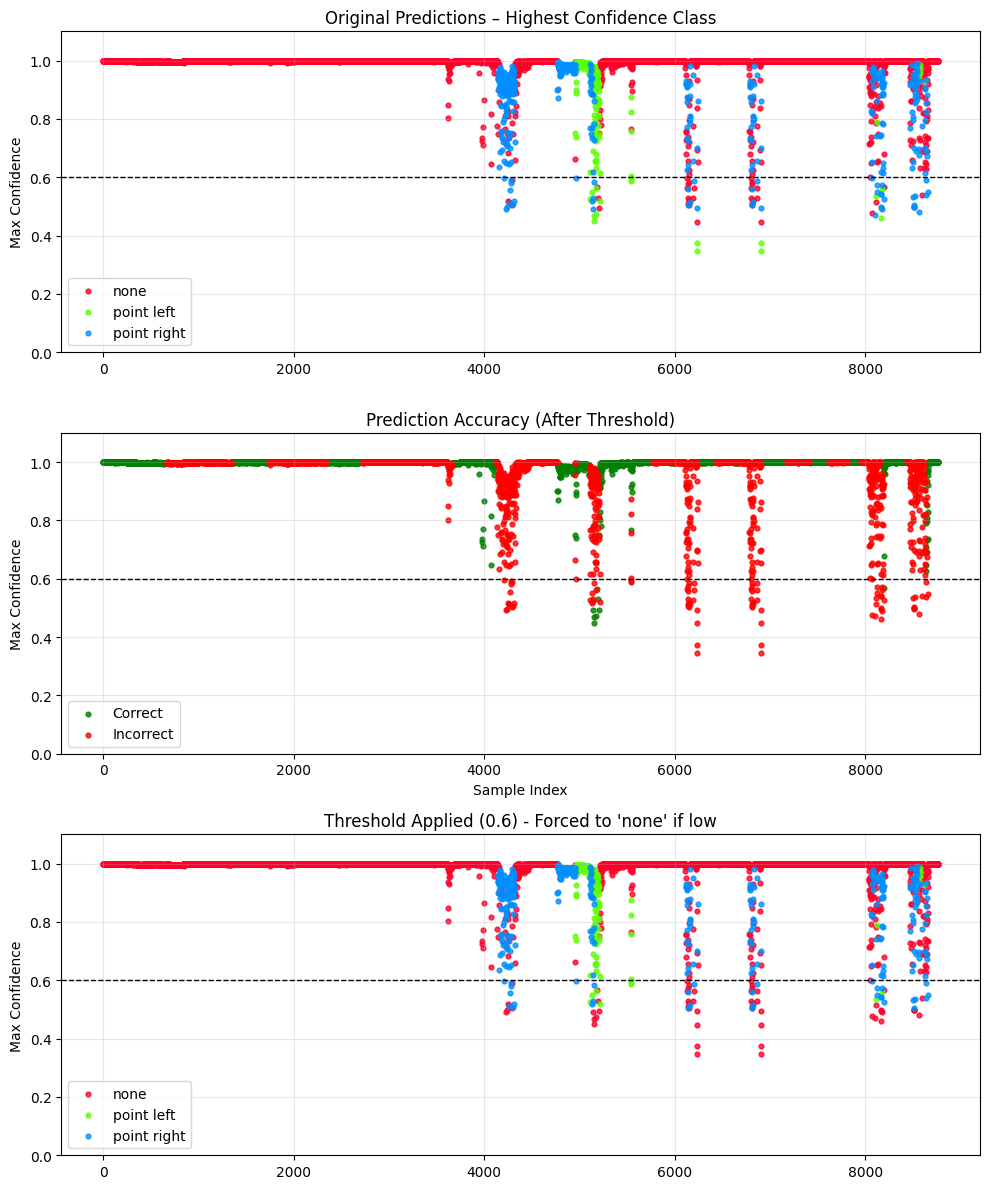

In [39]:
# ------------------------
# 1. Prepare Test Features
# ------------------------
# Use the testing2 dataframe we loaded from the new CSV
true_labels2 = testing2["label"]
X_features = testing2.drop(columns=['label'], errors='ignore')

# Vectorized coercion to ensure all sensor data is numeric
X_features = X_features.apply(pd.to_numeric, errors='coerce').fillna(0)

# CRITICAL: Align columns with your ORIGINAL training features
# Replace 'X_train' with whatever your training DataFrame was named (e.g., 'df_train' or 'data')
X_features = X_features[X_train.columns] 

# Convert to PyTorch tensor and move to GPU/CPU
X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# ------------------------
# 2. Inference
# ------------------------
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    new_probs = torch.softmax(new_logits, dim=1)
    # Get the highest probability and the corresponding class index
    max_probs, max_classes = torch.max(new_probs, dim=1)

# Convert tensors to CPU numpy for thresholding and plotting
max_probs = max_probs.cpu().numpy()
max_classes = max_classes.cpu().numpy().astype(int)
true_numeric2 = true_labels2.reset_index(drop=True).values.astype(int)

# ------------------------
# 3. Thresholding Logic (Fixed)
# ------------------------
pred_classes_thresh = max_classes.copy()
# Map low confidence to the EXISTING 'none' index (usually 3)
none_class_idx = mapping.get('none', 3) 
pred_classes_thresh[max_probs < 0.5] = none_class_idx

# ------------------------
# 4. Visualization (3 Subplots)
# ------------------------
fig, (ax1, ax3, ax2) = plt.subplots(3, 1, figsize=(10, 12))
cmap = plt.colormaps.get_cmap("gist_rainbow")

# Plot 1: Raw Predictions
for label, class_idx in mapping.items():
    mask = (max_classes == class_idx)
    indices = np.flatnonzero(mask)
    if len(indices) == 0: continue
    
    color = cmap(class_idx / len(mapping))
    ax1.scatter(indices, max_probs[indices], s=12, alpha=0.8, label=label, color=color)

ax1.set_ylabel("Max Confidence")
ax1.set_ylim(0, 1.1)
ax1.set_title("Original Predictions – Highest Confidence Class")
ax1.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Thresholded predictions
for label, class_idx in mapping.items():
    mask = (pred_classes_thresh == class_idx)
    indices = np.flatnonzero(mask)
    if len(indices) == 0: continue
    
    color = cmap(class_idx / len(mapping))
    ax2.scatter(indices, max_probs[indices], s=12, alpha=0.8, label=label, color=color)

ax2.set_ylabel("Max Confidence")
ax2.set_ylim(0, 1.1)
ax2.set_title(f"Threshold Applied ({conf_thres}) - Forced to 'none' if low")
ax2.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Accuracy (Correct vs Incorrect)
correct_mask = (pred_classes_thresh == true_numeric2)
incorrect_mask = (pred_classes_thresh != true_numeric2)

ax3.scatter(np.flatnonzero(correct_mask), max_probs[correct_mask], 
            s=12, alpha=0.8, label="Correct", color="green")
ax3.scatter(np.flatnonzero(incorrect_mask), max_probs[incorrect_mask], 
            s=12, alpha=0.8, label="Incorrect", color="red")

ax3.set_xlabel("Sample Index")
ax3.set_ylabel("Max Confidence")
ax3.set_ylim(0, 1.1)
ax3.set_title("Prediction Accuracy (After Threshold)")
ax3.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluation


## Confusion Matrix

In [40]:
true_numeric = true_numeric2

In [41]:
print(f"Number of NaNs in true_numeric: {np.isnan(true_numeric).sum()}")

Number of NaNs in true_numeric: 0


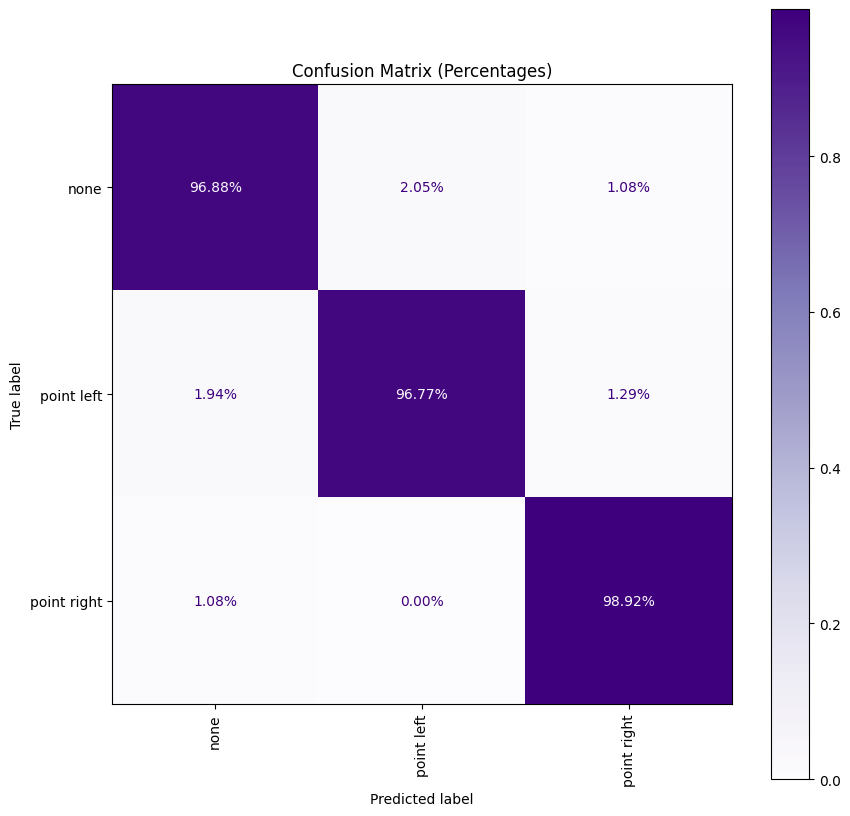

In [42]:
# 1. Ensure numeric types and clean NaNs
valid_mask = ~np.isnan(true_numeric2) # Using 'true_numeric2' from your latest test
true_numeric_clean = true_numeric2[valid_mask].astype(int)
max_classes_clean = max_classes[valid_mask].astype(int)

# 2. Calculate the matrix
# Use 'labels' to force the matrix to include all classes even if they weren't predicted
class_indices = list(range(len(mapping)))
cm = confusion_matrix(true_numeric_clean, max_classes_clean, labels=class_indices, normalize='true')

# 3. Plot with normalization ('true' normalizes by rows/actual classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=list(mapping.keys())
)

# Plotting with percentages makes it much easier to read
disp.plot(cmap='Purples', ax=ax, values_format='.2%', xticks_rotation='vertical')

plt.title("Confusion Matrix (Percentages)")
plt.show()

In [43]:
print("Average Confidence per Predicted Class:\n")

# Use the actual mapping to stay consistent with your 4 classes
for class_name, class_idx in mapping.items():
    # 1. Create a mask for samples assigned to this class (after thresholding)
    class_mask = (pred_classes_thresh == class_idx)

    # 2. Extract the original probabilities for these samples
    confidences_for_class = max_probs[class_mask]

    if len(confidences_for_class) > 0:
        avg_confidence = np.mean(confidences_for_class)
        print(f"{class_name.capitalize()}: {avg_confidence:.4f} (Samples: {len(confidences_for_class)})")
    else:
        print(f"{class_name.capitalize()}: No predictions made for this class.")

Average Confidence per Predicted Class:

None: 0.9904 (Samples: 8018)
Point left: 0.9274 (Samples: 236)
Point right: 0.8869 (Samples: 512)


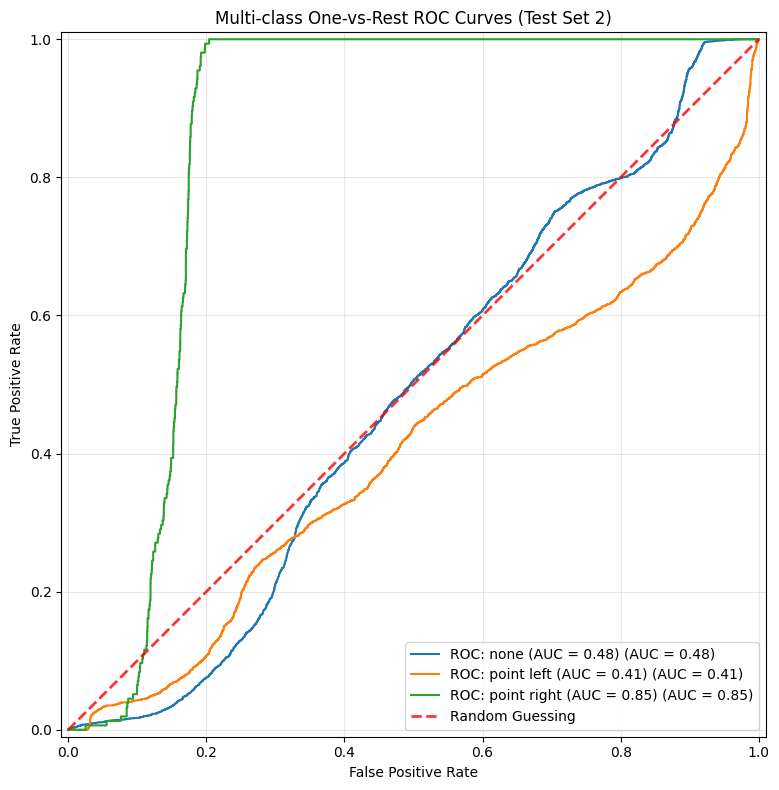

In [44]:
# ------------------------
# 1. Prepare Features & Labels
# ------------------------
# Use the mapped labels from your second test set
true_labels = true_numeric2 

X_features = testing2.copy()
X_features = X_features.drop(columns=['label'], errors='ignore')

# Vectorized numeric conversion
X_features = X_features.apply(pd.to_numeric, errors='coerce').fillna(0)

# CRITICAL: Align columns using the original training DataFrame template
# Change 'X_train' to whatever your training features were named (e.g. df_train)
X_features = X_features[X_train.columns] 

# Convert to Tensor for the model
X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# ------------------------
# 2. Model Inference
# ------------------------
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    # ROC curves require probabilities, so we MUST use softmax
    new_probs = torch.softmax(new_logits, dim=1)

# ------------------------
# 3. Data Prep for ROC
# ------------------------
# Move probabilities to CPU numpy for Scikit-Learn
y_score = new_probs.cpu().numpy()

# Convert true labels to One-Hot encoding (Required for Multi-class ROC)
label_binarizer = LabelBinarizer().fit(true_labels)
y_onehot_test = label_binarizer.transform(true_labels)

# ------------------------
# 4. Plotting One-vs-Rest ROC Curves
# ------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# Get the list of class names from your mapping (e.g., ['rock', 'paper', ...])
class_names = list(mapping.keys())

for class_id, class_name in enumerate(class_names):
    # Calculate specific AUC for this class to put in the legend
    fpr, tpr, _ = roc_curve(y_onehot_test[:, class_id], y_score[:, class_id])
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve for this class
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score[:, class_id],
        name=f"ROC: {class_name} (AUC = {roc_auc:.2f})",
        ax=ax,
        plot_chance_level=False # We will add a custom one for better styling
    )

# Add a professional "Chance Level" diagonal line
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Random Guessing', alpha=.8)

# Styling
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Multi-class One-vs-Rest ROC Curves (Test Set 2)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## K-Fold

In [45]:
# # Ensure reproducibility
# torch.manual_seed(SEED)

# # 1. Initialize storage for metrics
# all_train_losses = [] 
# all_test_losses  = [] 
# fold_train_accs = [] 
# fold_test_accs = [] 
# fold_precisions = []
# fold_recalss = []
# fold_f1_scores = []

# # Prepare data for StratifiedKFold (requires numpy for indices)
# X_np = X.numpy()
# y_np = y.numpy()

# skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# # ------------------------
# # K-Fold Loop
# # ------------------------
# for fold, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
#     print(f"\n{'='*40}")
#     print(f"   FOLD {fold + 1} / {N_FOLDS}")
#     print(f"{'='*40}")

#     # Split and move to device
#     X_train_fold, y_train_fold = X[train_idx].to(device), y[train_idx].long().to(device)
#     X_test_fold, y_test_fold   = X[test_idx].to(device), y[test_idx].long().to(device)

#     # Re-initialize Model, Loss, and Optimizer for a fresh start each fold
#     model = RPSModel(input_features=input_features, output_features=classes).to(device)
#     loss_fn = nn.CrossEntropyLoss()
    
#     # Using Adam for better stability with unscaled sensor features
#     optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

#     train_losses_per_epoch = []
#     test_losses_per_epoch = []
    
#     for epoch in range(EPOCHS):
#         ### Training Phase
#         model.train()
#         y_logits = model(X_train_fold)
#         y_pred = torch.argmax(y_logits, dim=1)
        
#         loss = loss_fn(y_logits, y_train_fold)
#         train_acc = accuracy_fn(y_true=y_train_fold, y_pred=y_pred)
        
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         ### Validation/Test Phase (for this fold)
#         model.eval()
#         with torch.inference_mode():
#             test_logits = model(X_test_fold)
#             test_pred = torch.argmax(test_logits, dim=1)
#             test_loss = loss_fn(test_logits, y_test_fold)
#             test_acc = accuracy_fn(y_true=y_test_fold, y_pred=test_pred)

#         train_losses_per_epoch.append(loss.item())
#         test_losses_per_epoch.append(test_loss.item())

#         if epoch % 100 == 0 or epoch == EPOCHS - 1:
#             print(f"   Epoch: {epoch} | Train Loss: {loss:.5f}, Acc: {train_acc:.2f}% | Test Loss: {test_loss:.5f}, Acc: {test_acc:.2f}%")

#     # Store final metrics for this fold
#     all_train_losses.append(train_losses_per_epoch)
#     all_test_losses.append(test_losses_per_epoch)
#     fold_train_accs.append(train_acc)
#     fold_test_accs.append(test_acc)

#     # Detailed report for the current fold
#     report = classification_report(
#         y_test_fold.cpu(), 
#         test_pred.cpu(), 
#         target_names=list(mapping.keys()), 
#         output_dict=True, 
#         zero_division=0
#     )
    
#     fold_precisions.append(report['macro avg']['precision'])
#     fold_recalss.append(report['macro avg']['recall'])
#     fold_f1_scores.append(report['macro avg']['f1-score'])

# # ------------------------
# # 5. Visualizing Cross-Validation Progress
# # ------------------------
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# for i, losses in enumerate(all_train_losses):
#     plt.plot(losses, label=f'Fold {i+1}', alpha=0.6)
# plt.title('Training Loss - All Folds')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.subplot(1, 2, 2)
# for i, losses in enumerate(all_test_losses):
#     plt.plot(losses, label=f'Fold {i+1}', alpha=0.6)
# plt.title('Validation Loss - All Folds')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.tight_layout()
# plt.show()

# # ------------------------
# # 6. Final Summary Statistics
# # ------------------------
# print(f"\n{'='*40}")
# print(f"   K-FOLD FINAL SUMMARY")
# print(f"{'='*40}")
# for i, (tr, te) in enumerate(zip(fold_train_accs, fold_test_accs)):
#     print(f"   Fold {i+1}: Train {tr:.2f}%  |  Test {te:.2f}%")

# print(f"\n   Mean Test Acc : {np.mean(fold_test_accs):.2f}% (+/- {np.std(fold_test_accs):.2f}%)")
# print(f"   Mean F1-Score : {np.mean(fold_f1_scores):.3f}")
# print(f"   Mean Precision: {np.mean(fold_precisions):.3f}")
# print(f"   Mean Recall   : {np.mean(fold_recalss):.3f}")

## Summary

In [47]:
print("\n" + "="*50)
print("           FINAL PERFORMANCE SUMMARY")
print("="*50)

# 1. Accuracy Comparison
acc_raw = accuracy_score(true_numeric, max_classes)
acc_thresh = accuracy_score(true_numeric, pred_classes_thresh)

print(f"Overall Accuracy (Raw):         {acc_raw:.4f}")
print(f"Overall Accuracy (Thresholded): {acc_thresh:.4f}")
print(f"F1-Score (Weighted):            {f1_score(true_numeric, max_classes, average='weighted'):.4f}")

# 2. Cross-Validation Results
print(f"\nK-Fold Mean Test Accuracy:      {np.mean(fold_test_accs):.2f}%")
print(f"K-Fold Std Deviation:           {np.std(fold_test_accs):.2f}%")

# 3. Average Confidence (Clean Logic)
print("\n--- Average Confidence per Predicted Class ---")
for class_name, class_idx in mapping.items():
    # Use the thresholded predictions to see how confident the model was for each group
    class_mask = (pred_classes_thresh == class_idx)
    confidences_for_class = max_probs[class_mask]

    if len(confidences_for_class) > 0:
        avg_confidence = np.mean(confidences_for_class)
        print(f"{class_name.capitalize():<10}: {avg_confidence:.4f} (N={len(confidences_for_class)})")
    else:
        print(f"{class_name.capitalize():<10}: No predictions for this class.")


           FINAL PERFORMANCE SUMMARY
Overall Accuracy (Raw):         0.4695
Overall Accuracy (Thresholded): 0.4700
F1-Score (Weighted):            0.3073


NameError: name 'fold_test_accs' is not defined

# Which features are the most important?

Baseline Accuracy on Test Set 2: 46.95%


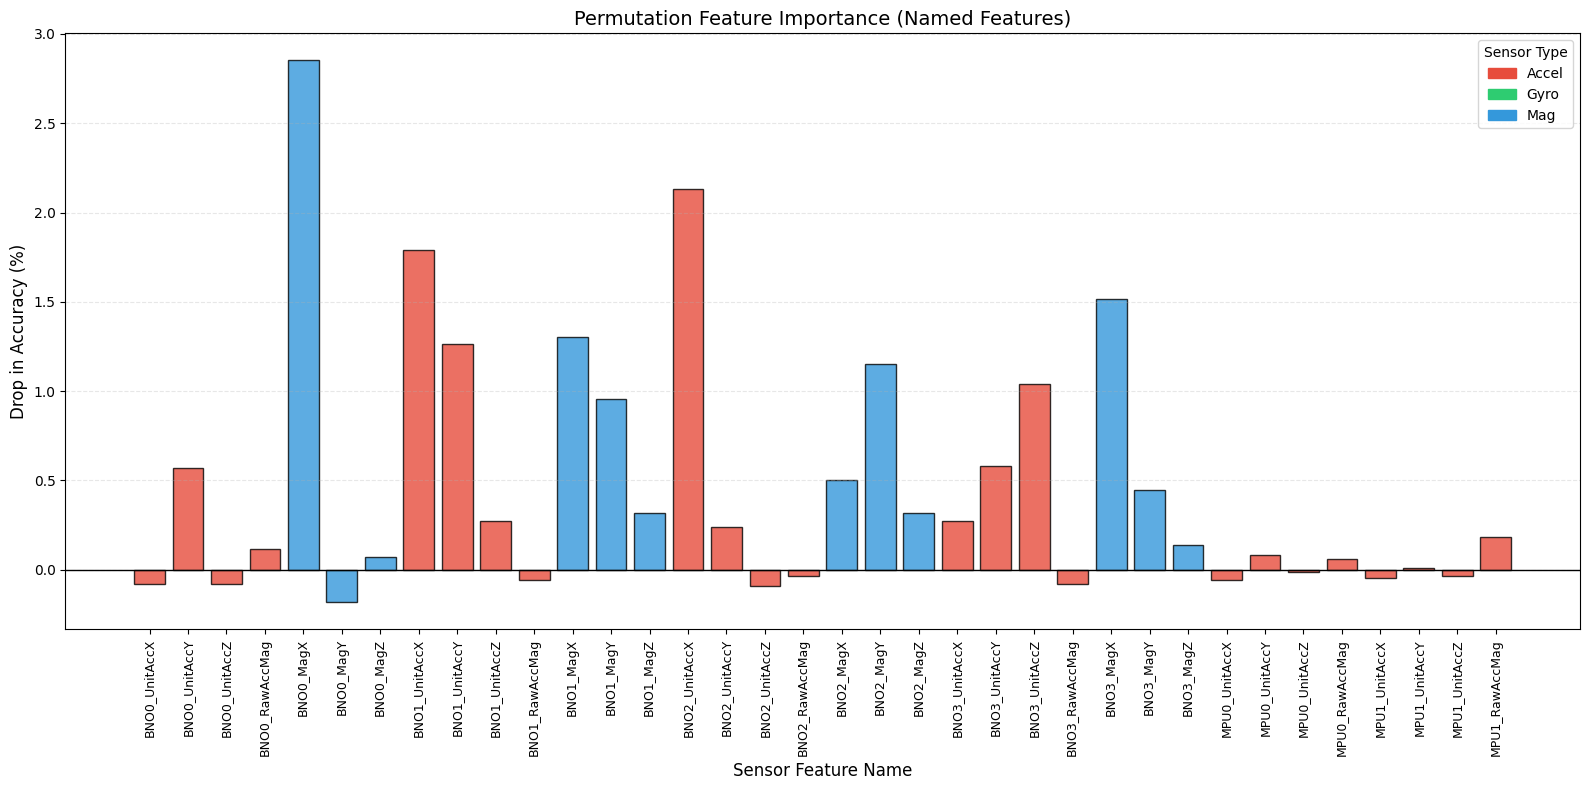


--- Top 5 Most Critical Features ---
1. BNO0_MagX            | Importance Score: 2.8519
2. BNO2_UnitAccX        | Importance Score: 2.1332
3. BNO1_UnitAccX        | Importance Score: 1.7910
4. BNO3_MagX            | Importance Score: 1.5172
5. BNO1_MagX            | Importance Score: 1.3005


In [48]:
# 1. Prepare Data and Baseline
y_new_tensor = torch.tensor(true_numeric2).long().to(device)
model_4.eval()

with torch.inference_mode():
    baseline_logits = model_4(X_new) 
    baseline_pred = torch.argmax(baseline_logits, dim=1)
    baseline_acc = accuracy_fn(y_true=y_new_tensor, y_pred=baseline_pred)

print(f"Baseline Accuracy on Test Set 2: {baseline_acc:.2f}%")

# 2. Extract Feature Names from your training template
# Using X_train.columns ensures we match the specific indices used by the model
feature_names = list(X_train.columns)
num_features = len(feature_names)

# 3. Calculate Importance per Feature
importances = []
for i in range(num_features):
    X_permuted = X_new.clone()
    X_permuted[:, i] = X_new[torch.randperm(X_new.shape[0]), i] 

    with torch.inference_mode():
        perm_logits = model_4(X_permuted)
        perm_pred = torch.argmax(perm_logits, dim=1)
        perm_acc = accuracy_fn(y_true=y_new_tensor, y_pred=perm_pred)
    
    importances.append(baseline_acc - perm_acc)

# 4. Define Feature Groups (Mappings stay the same, but colors apply to names)
group_colors = {
    'Accel': '#e74c3c', # Red
    'Gyro':  '#2ecc71', # Green
    'Mag':   '#3498db'  # Blue
}

feature_colors = []
for i in range(num_features):
    assigned_color = '#95a5a6' # Default Gray
    name_lower = feature_names[i].lower()
    
    if 'acc' in name_lower:
        assigned_color = group_colors['Accel']
    elif 'gyr' in name_lower:
        assigned_color = group_colors['Gyro']
    elif 'mag' in name_lower:
        assigned_color = group_colors['Mag']
    
    feature_colors.append(assigned_color)

# 5. Plotting with Feature Names
plt.figure(figsize=(16, 8))
plt.bar(feature_names, importances, color=feature_colors, edgecolor='black', alpha=0.8)

plt.xlabel("Sensor Feature Name", fontsize=12)
plt.ylabel("Drop in Accuracy (%)", fontsize=12)
plt.title("Permutation Feature Importance (Named Features)", fontsize=14)
plt.axhline(0, color='black', lw=1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Rotate labels so they don't overlap
plt.xticks(rotation=90, fontsize=9)

# Custom Legend
handles = [plt.Rectangle((0,0),1,1, color=group_colors[g]) for g in group_colors]
plt.legend(handles, group_colors.keys(), title="Sensor Type", loc='upper right')

plt.tight_layout()
plt.show()

# 6. Print Top 5 Critical Features by Name
sorted_idx = np.argsort(importances)[::-1]
print("\n--- Top 5 Most Critical Features ---")
for i in range(5):
    idx = sorted_idx[i]
    print(f"{i+1}. {feature_names[idx]:<20} | Importance Score: {importances[idx]:.4f}")

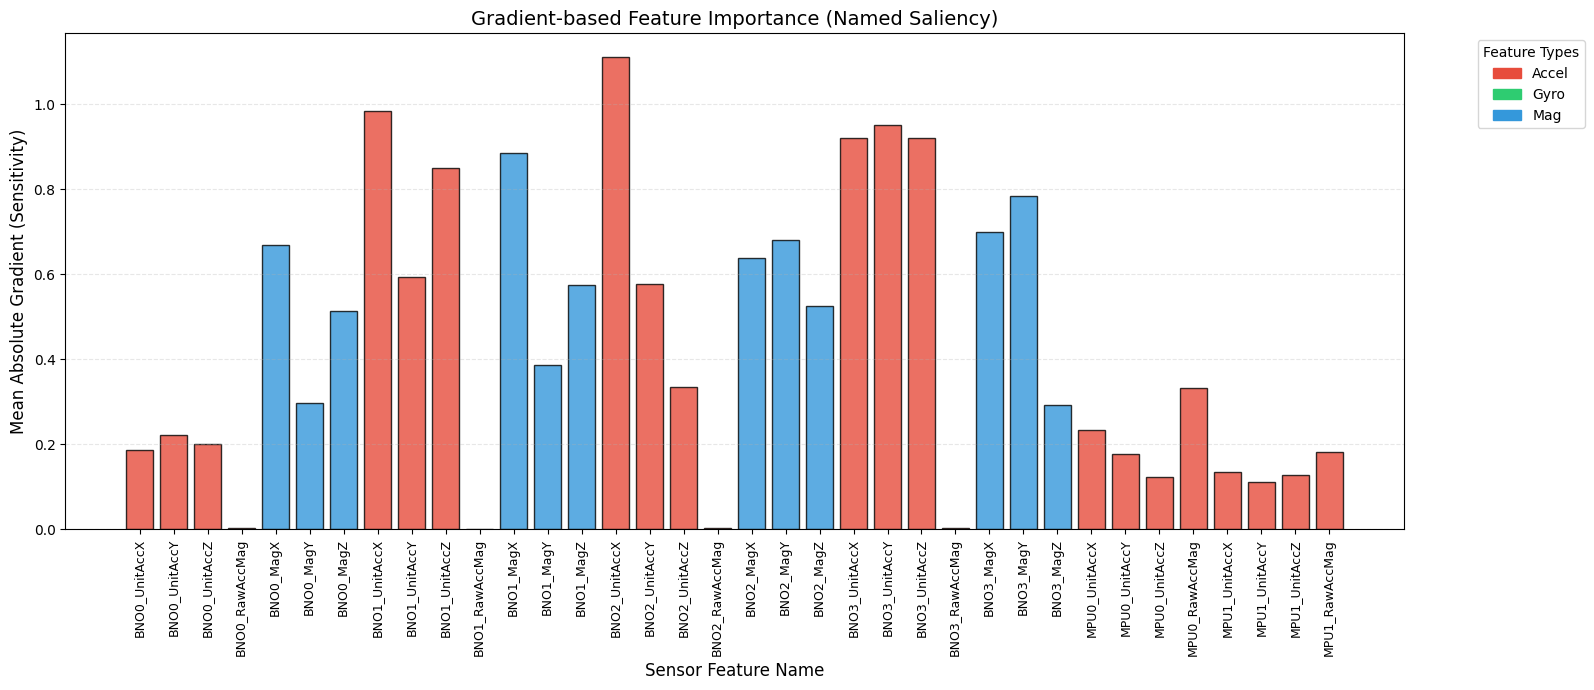


--- Top 5 Features the Model is 'Looking At' (Saliency) ---
1. BNO2_UnitAccX        | Gradient Sensitivity: 1.110843
2. BNO1_UnitAccX        | Gradient Sensitivity: 0.983182
3. BNO3_UnitAccY        | Gradient Sensitivity: 0.950369
4. BNO3_UnitAccX        | Gradient Sensitivity: 0.920835
5. BNO3_UnitAccZ        | Gradient Sensitivity: 0.919187


In [49]:
# 1. Prepare the input for gradients using X_new (Test Set 2)
X_grad_input = X_new.clone().detach().requires_grad_(True)

# 2. Forward pass (Manual eval, no inference_mode because we need the gradient graph)
model_4.eval()
output = model_4(X_grad_input)

# 3. Backward pass on the sum of max logits
# This calculates how much the output 'wiggles' relative to the input features
output.max(dim=1).values.sum().backward()

# 4. Extract Importance (Mean Absolute Gradient)
importances = X_grad_input.grad.abs().mean(dim=0).cpu().detach().numpy()

# 5. Get Feature Names from your original DataFrame
feature_names = list(X_train.columns)
num_features = len(feature_names)

# 6. Define Colors based on feature name keywords
group_colors = {
    'Accel': '#e74c3c', # Red
    'Gyro':  '#2ecc71', # Green
    'Mag':   '#3498db'  # Blue
}

feature_colors = []
for i in range(num_features):
    assigned_color = '#95a5a6' # Default gray
    name_lower = feature_names[i].lower()
    
    if 'acc' in name_lower:
        assigned_color = group_colors['Accel']
    elif 'gyr' in name_lower:
        assigned_color = group_colors['Gyro']
    elif 'mag' in name_lower:
        assigned_color = group_colors['Mag']
        
    feature_colors.append(assigned_color)

# 7. Plotting with Feature Names
plt.figure(figsize=(16, 7))
plt.bar(feature_names, importances, color=feature_colors, edgecolor='black', alpha=0.8)

plt.title("Gradient-based Feature Importance (Named Saliency)", fontsize=14)
plt.xlabel("Sensor Feature Name", fontsize=12)
plt.ylabel("Mean Absolute Gradient (Sensitivity)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Rotate labels for readability
plt.xticks(rotation=90, fontsize=9)

# Create legend
handles = [plt.Rectangle((0,0),1,1, color=group_colors[g]) for g in group_colors]
plt.legend(handles, group_colors.keys(), title="Feature Types", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Print Top 5 Saliency Features
sorted_idx = np.argsort(importances)[::-1]
print("\n--- Top 5 Features the Model is 'Looking At' (Saliency) ---")
for i in range(5):
    idx = sorted_idx[i]
    print(f"{i+1}. {feature_names[idx]:<20} | Gradient Sensitivity: {importances[idx]:.6f}")

In [50]:
mapping2

{'none': 0, 'point left': 1, 'point right': 2}

# Live Testing

In [51]:
GESTURE_MAP = {}
for key in mapping2:
    GESTURE_MAP[mapping2[key]] = key
GESTURE_MAP    

{0: 'none', 1: 'point left', 2: 'point right'}

In [52]:
import asyncio
import websockets
import torch
import numpy as np

# 1. Configuration
PICO_URI = "ws://192.168.4.1:81"
CONFIDENCE_THRESHOLD = 0.5
# GESTURE_MAP = {0: "None", 1: "Paper", 2: "Rock", 3: "Scissors"}

async def live_glove_inference():
    # Detect expected features from the actual model
    # expected_features = model_4.state_dict()['fc1.weight'].shape[1]
    # print(f"Model verified: Expecting {expected_features} features per row.")

    while True:
        try:
            # Added ping_interval=None to stop the client from timing out the Pico
            async with websockets.connect(PICO_URI, ping_interval=None) as websocket:
                print(f"\n--- Connected to Glove at {PICO_URI} ---")
                
                # The first message is the header; we grab it once and move on
                header = await websocket.recv()
                print(f"Header ignored. Streaming data...")

                model_4.eval()
                
                while True:
                    # Receive raw CSV string
                    raw_message = await websocket.recv()
                    
                    try:
                        # Fast conversion
                        data_points = [float(x) for x in raw_message.split(',')]
                        
                        # Guard rail for malformed strings
                        # if len(data_points) != expected_features:
                        #     continue

                        # Move to device (CPU is usually faster for single-row inference)
                        input_tensor = torch.tensor(data_points, dtype=torch.float32).unsqueeze(0).to(device)
                        
                        with torch.inference_mode():
                            logits = model_4(input_tensor)
                            probs = torch.softmax(logits, dim=1)
                            max_conf, pred_idx = torch.max(probs, dim=1)
                        
                        confidence = max_conf.item()
                        
                        if confidence > CONFIDENCE_THRESHOLD:
                            gesture = GESTURE_MAP[pred_idx.item()]
                            # \r allows the line to overwrite itself for a clean dashboard look
                            print(f"Detected: {gesture:10} | Confidence: {confidence:.2f}", end="\r")
                        else:
                            print(f"Detected: {'None':10} | Confidence: {confidence:.2f}", end="\r")

                    except (ValueError, IndexError):
                        # Skips any stray text or empty lines
                        continue

        except (websockets.ConnectionClosed, OSError) as e:
            print(f"\n[Status] Connection dropped ({e}). Reconnecting...")
            await asyncio.sleep(1)

# Run the live loop
# await live_glove_inference()

In [53]:
import asyncio
import websocket

# These are the indices of Accel and Mag data, skipping all 'Gyr' columns
# Total expected features: 36
KEEP_INDICES = [
    # BNO0
    0, 1, 2, 3, 7, 8, 9,
    # BNO1
    10, 11, 12, 13, 17, 18, 19,
    # BNO2
    20, 21, 22, 23, 27, 28, 29,
    # BNO3
    30, 31, 32, 33, 37, 38, 39,
    # MPU0
    40, 41, 42, 43, 
    # MPU1
    47, 48, 49, 50
]

def run_live_inference_hardcoded():
    # Model check
    # expected_features = model_4.state_dict()['fc1.weight'].shape[1]
    # if len(KEEP_INDICES) != expected_features:
    #     print(f"Error: Mask size ({len(KEEP_INDICES)}) != Model inputs ({expected_features})")
    #     return

    try:
        ws = websocket.create_connection(PICO_URI, timeout=5)
        print(f"--- Connected to Glove at {PICO_URI} ---")
        ws.recv() # Skip Header
        model_4.eval()

        while True:
            raw_message = ws.recv()
            if not raw_message: continue

            try:
                # 1. Parse all 54 incoming floats
                full_data = [float(x) for x in raw_message.split(',')]
                
                # 2. Extract only the Accel/Mag indices
                filtered_data = [full_data[i] for i in KEEP_INDICES]
                
                # 3. Predict
                input_tensor = torch.tensor(filtered_data, dtype=torch.float32).unsqueeze(0).to(device)
                
                with torch.inference_mode():
                    logits = model_4(input_tensor)
                    probs = torch.softmax(logits, dim=1)
                    max_conf, pred_idx = torch.max(probs, dim=1)
                
                confidence = max_conf.item()
                
                # 4. Display Result
                if confidence > CONFIDENCE_THRESHOLD:
                    gesture = GESTURE_MAP[pred_idx.item()]
                    print(f"Detected: {gesture:10} | Confidence: {confidence:.2f}", end="\r")
                else:
                    print(f"Detected: {'None':10} | Confidence: {confidence:.2f}", end="\r")

            except (ValueError, IndexError):
                continue

    except KeyboardInterrupt:
        print("\nStopping...")
    except Exception as e:
        print(f"\nConnection Error: {e}")
    finally:
        if 'ws' in locals(): ws.close()

run_live_inference_hardcoded()


Connection Error: timed out


In [54]:
import torch
import websocket
import numpy as np
from collections import deque
import time

# --- Configuration (Ensure these match your training) ---
WINDOW_SIZE = 5  # Match the window size you used in your CSV script
PICO_URI = "ws://192.168.4.1:81"
CONFIDENCE_THRESHOLD = 0.8
GESTURE_MAP = {0: "None", 1: "Paper", 2: "Rock", 3: "Scissors"}

# Accel and Mag data indices (36 total)
KEEP_INDICES = [
    0, 1, 2, 3, 7, 8, 9, 10, 11, 12, 13, 17, 18, 19,
    20, 21, 22, 23, 27, 28, 29, 30, 31, 32, 33, 37, 
    38, 39, 40, 41, 42, 43, 47, 48, 49, 50
]

def run_live_inference_windowed(model):
    # 1. Initialize sliding window buffer
    # Each entry will be the 36 filtered features
    window_buffer = deque(maxlen=WINDOW_SIZE)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    try:
        ws = websocket.create_connection(PICO_URI, timeout=5)
        print(f"--- Connected to Glove at {PICO_URI} ---")
        print(f"--- Using Window Size: {WINDOW_SIZE} ---")
        ws.recv() # Skip Header

        while True:
            raw_message = ws.recv()
            if not raw_message: continue

            try:
                # 2. Parse and Filter
                full_data = [float(x) for x in raw_message.split(',')]
                filtered_sample = [full_data[i] for i in KEEP_INDICES]
                
                # 3. Add to sliding window
                window_buffer.append(filtered_sample)

                # Wait until buffer is full before predicting
                if len(window_buffer) < WINDOW_SIZE:
                    continue

                # 4. Calculate Stats (Mean & Variance)
                # Convert buffer to (WINDOW_SIZE, 36) array
                data_window = np.array(window_buffer)
                means = np.mean(data_window, axis=0)
                variances = np.var(data_window, axis=0)

                # 5. Prepare Input Tensor
                # Option A: If your model was trained on [Means, Variances] (72 features)
                combined_input = np.concatenate([means, variances])
                
                # Option B: If your model only uses Means (36 features)
                # combined_input = means 

                input_tensor = torch.tensor(combined_input, dtype=torch.float32).unsqueeze(0).to(device)
                
                # 6. Inference
                with torch.inference_mode():
                    logits = model(input_tensor)
                    probs = torch.softmax(logits, dim=1)
                    max_conf, pred_idx = torch.max(probs, dim=1)
                
                confidence = max_conf.item()
                
                # 7. Display
                if confidence > CONFIDENCE_THRESHOLD:
                    gesture = GESTURE_MAP[pred_idx.item()]
                    print(f"Detected: {gesture:10} | Conf: {confidence:.2f}", end="\r")
                else:
                    print(f"Detected: {'None':10} | Conf: {confidence:.2f}", end="\r")

            except (ValueError, IndexError):
                continue

    except KeyboardInterrupt:
        print("\nStopping Live Inference...")
    except Exception as e:
        print(f"\nError: {e}")
    finally:
        if 'ws' in locals(): ws.close()

# To run:
# run_live_inference_windowed(model_4)